# Compressed sensing

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Signal example

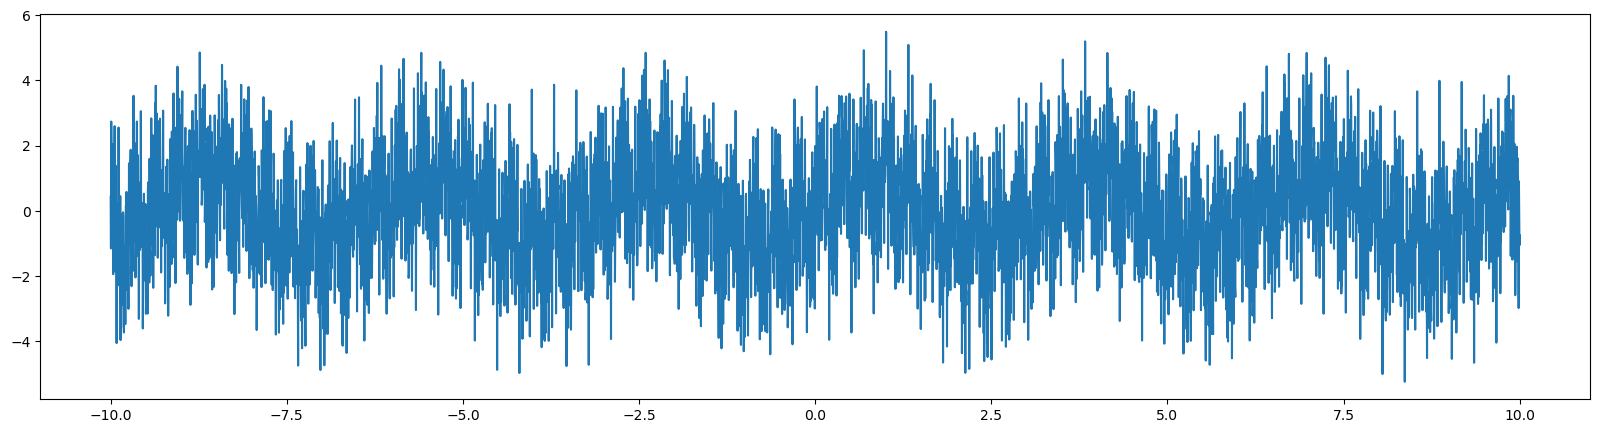

In [47]:
N = 5000

x = np.linspace(-10, 10, N)
fx = np.sin(120*x) + np.cos(300*x) + np.sin(20*x) + np.sin(2*x) + np.cos(556*x) + np.sin(2344*x)

plt.figure(figsize=(20, 5))
plt.plot(x, fx)

(1151, 0.2302)

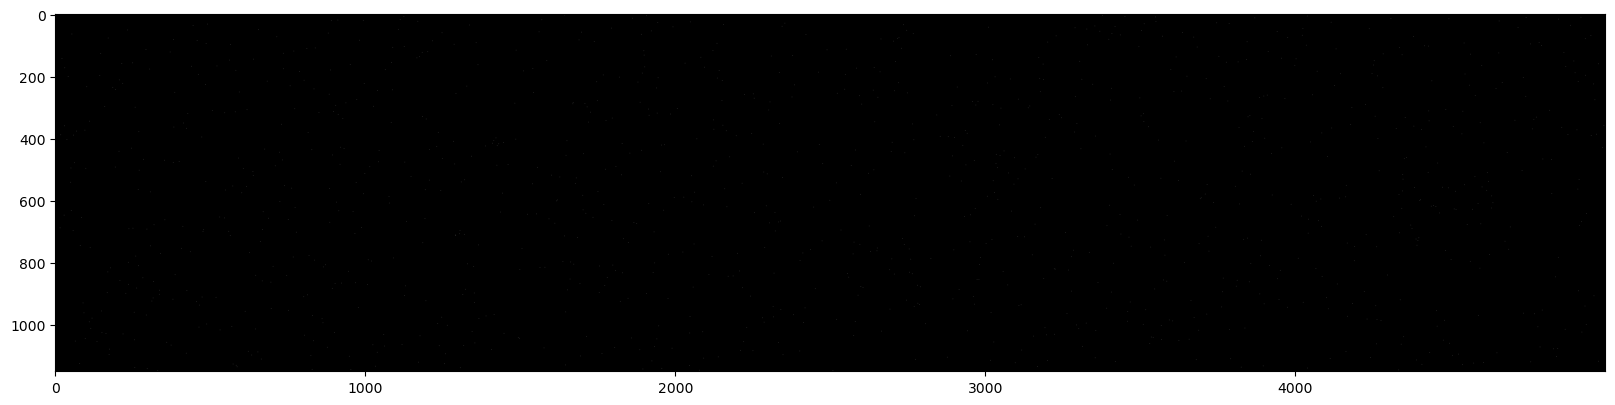

In [50]:
K_sparsity = 50 # upper bound on the amount of sparse modes
k1 = 5 # constant
n_measurements = int(k1*K_sparsity * np.log(N/K_sparsity))

perm = np.random.permutation(N)
C = np.eye(n_measurements, N)[:, perm]

plt.figure(figsize=(20, 5))
plt.imshow(C, cmap='gray')

n_measurements, n_measurements/N # proportion of N

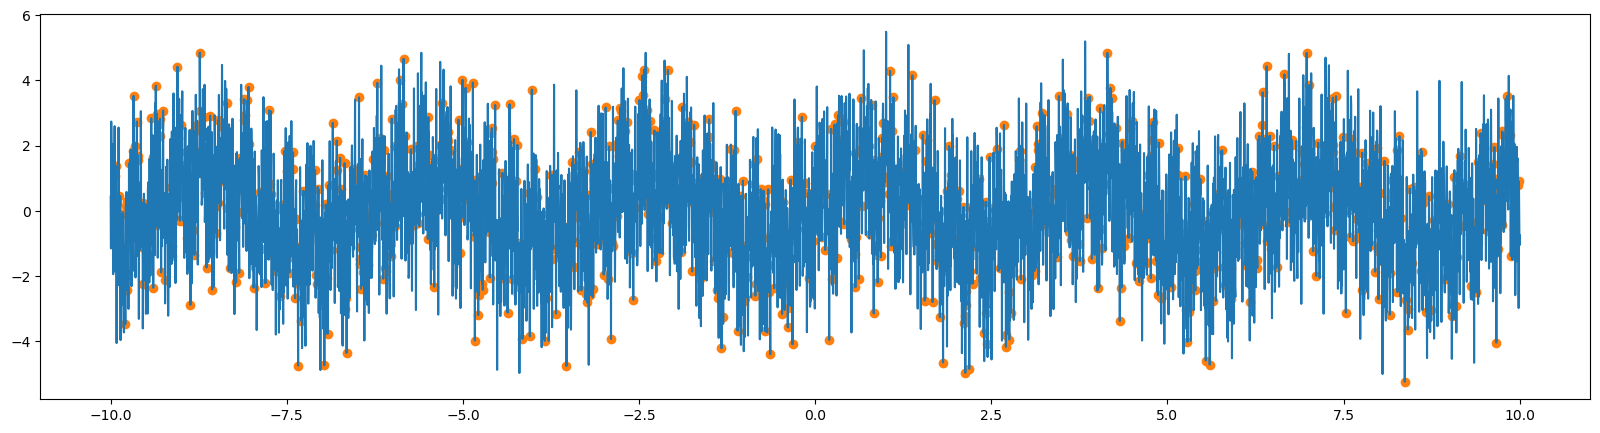

In [51]:
ft = C @ fx

plt.figure(figsize=(20, 5))
plt.plot(x, fx)
plt.scatter(x[np.argmax(C, axis=1)], ft, c='C1')

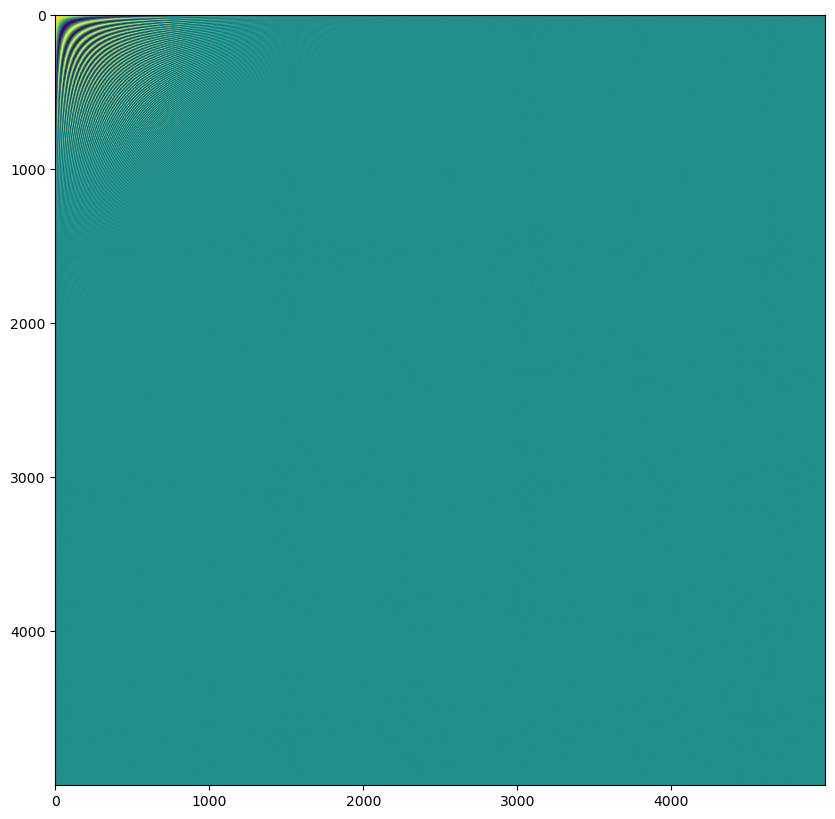

In [52]:
from scipy.fftpack import dct

Psi = dct(np.identity(N))
plt.figure(figsize=(10, 10))
plt.imshow(Psi)

In [53]:
C.shape, Psi.shape

((1151, 5000), (5000, 5000))

0 41765.02734375
100 3442.060302734375
200 2690.310546875
300 2101.22802734375
400 1602.178466796875
500 1188.8829345703125
600 859.5828247070312
700 595.959228515625
800 391.2772216796875
900 235.09036254882812
1000 116.56145477294922
1100 34.71038055419922
1200 8.033023834228516
1300 7.4048662185668945
1400 7.483858108520508
1500 7.521506309509277
1600 7.6684794425964355
1700 7.6898393630981445
1800 7.789399147033691
1900 7.888533115386963


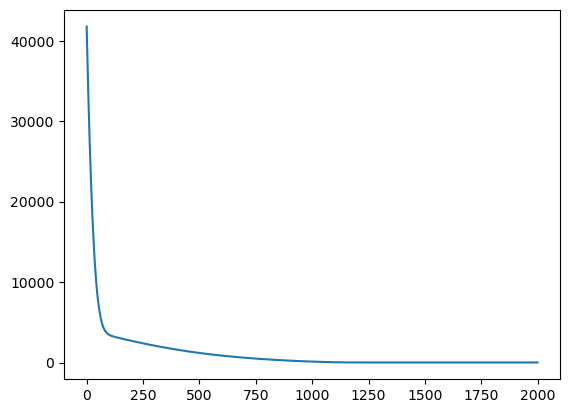

In [54]:
import torch 
from torch import nn

s = torch.randn(N, requires_grad=True)

C_torch = torch.tensor(C).to(torch.float)
Psi_torch = torch.tensor(Psi).to(torch.float)
Theta = C_torch @ Psi_torch
ft_torch = torch.tensor(ft).to(torch.float)

optim = torch.optim.Adam([s], lr=0.01)

mse = nn.MSELoss()

lam = 3.5

history = []

for i in range(2000):

    y = Theta @ s

    loss = lam * torch.mean((y - ft_torch)**2) + torch.norm(s, p=1)

    history.append(loss.item())
    
    if i % 100 == 0: print(i, history[-1])

    optim.zero_grad()
    loss.backward()
    optim.step()

plt.plot(history)

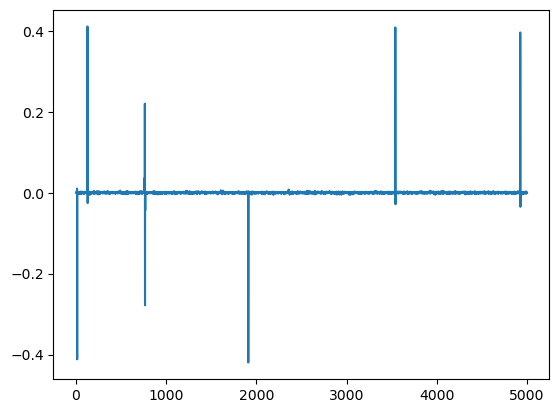

In [55]:
plt.plot(s.detach())

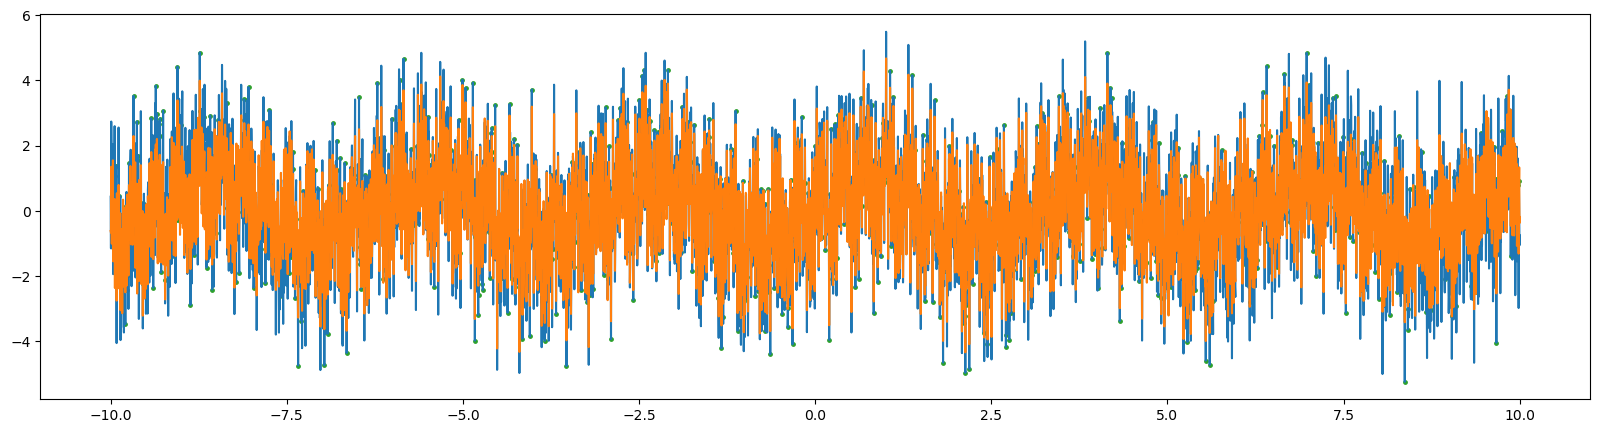

In [58]:
fx_recon = Psi_torch @ s

plt.figure(figsize=(20, 5))
plt.plot(x, fx)
plt.plot(x, fx_recon.detach().numpy())
plt.scatter(x[np.argmax(C, axis=1)], ft, c='C2', s=6)

## Image example

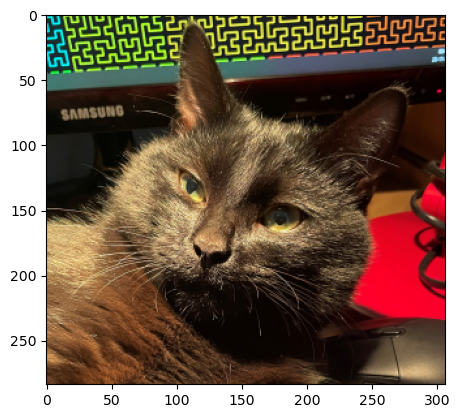

In [59]:
from PIL import Image

img = Image.open('../datasets/image_sample/kat.png')
img.load()
img = np.array(img, dtype=float)

plt.imshow(img.astype('uint8'), cmap="gray")

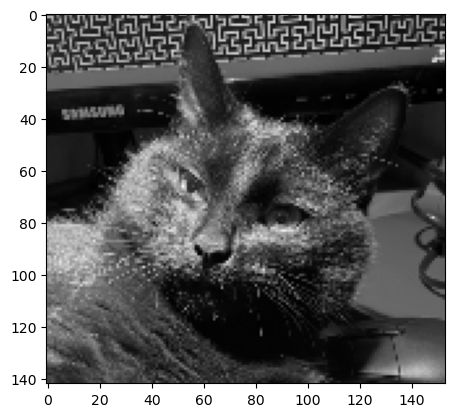

In [69]:
scale = 2
gray_img = img.mean(-1)/4
gray_img = gray_img[::scale, ::scale]

plt.imshow(gray_img, cmap="gray")

In [70]:
flatten_img = gray_img.flatten()
flatten_img.shape

(21726,)

In [72]:
N = flatten_img.shape[0]
K_sparsity = 2000
k1 = 3
n_measurements = int(k1*K_sparsity * np.log(N/K_sparsity))

idx = np.random.randint(N, size=n_measurements)
idx.shape, n_measurements/N

((14312,), 0.658749884930498)

In [73]:
y = flatten_img[idx]
y.shape

(14312,)

In [74]:
from scipy.fftpack import dct

Psi = dct(np.identity(N))
Theta = Psi[idx]

Psi.shape, Theta.shape

((21726, 21726), (14312, 21726))

0 83717.25
100 31301.84765625
200 15416.908203125
300 9914.51953125
400 7141.31591796875
500 5216.68017578125
600 3731.77685546875
700 2578.386474609375
800 1724.02880859375
900 1133.30078125
1000 765.497314453125
1100 561.6478881835938
1200 453.8048095703125
1300 389.85595703125
1400 344.1812744140625
1500 308.13330078125
1600 277.22393798828125
1700 250.79312133789062
1800 228.0463104248047
1900 208.1550750732422


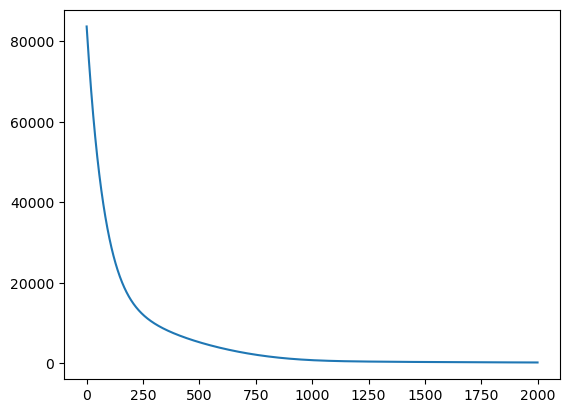

In [75]:
import torch 
from torch import nn

s = torch.randn(N, requires_grad=True)

Theta_torch = torch.tensor(Theta).to(torch.float)
y_sample = torch.tensor(y).to(torch.float)

optim = torch.optim.Adam([s], lr=0.005)

mse = nn.MSELoss()

lam = 1.5

history = []

for i in range(2000):

    y_sample_recon = Theta_torch @ s

    loss = lam * torch.mean((y_sample_recon - y_sample)**2) + torch.norm(s, p=1)

    history.append(loss.item())
    
    if i % 100 == 0: print(i, history[-1])

    optim.zero_grad()
    loss.backward()
    optim.step()

plt.plot(history)

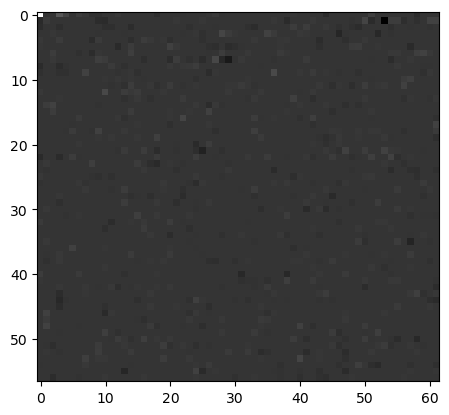

In [67]:
plt.imshow(s.detach().numpy().reshape(gray_img.shape), cmap='gray')

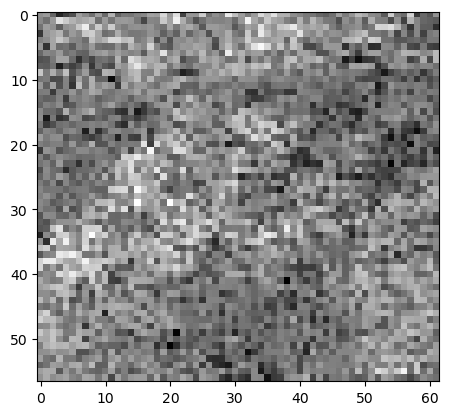

In [68]:
fx_recon = Psi @ s.detach().numpy()

plt.imshow(fx_recon.reshape(gray_img.shape), cmap='gray')

## Image example 2d DCT

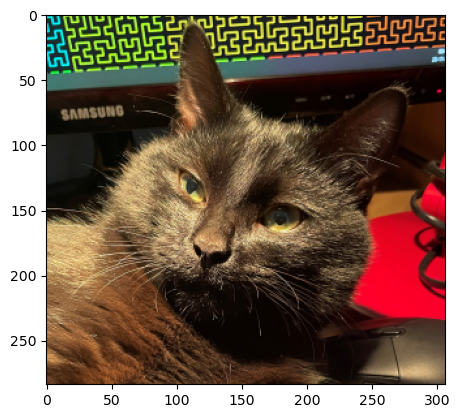

In [3]:
from PIL import Image

img_col = Image.open('../datasets/image_sample/kat.png')
img_col.load()
img_col = np.array(img_col, dtype=float)

plt.imshow(img_col.astype('uint8'), cmap="gray")

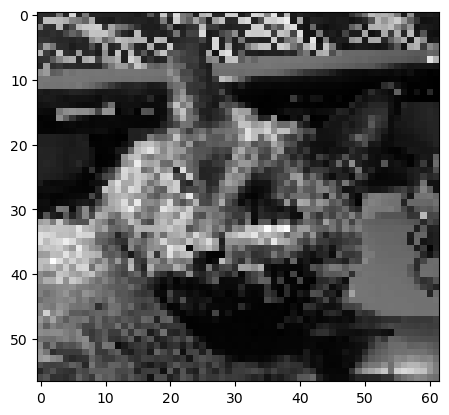

In [32]:
scale = 5
img = img_col.mean(-1)/4
img = img[::scale, ::scale]

plt.imshow(img, cmap="gray")

In [33]:
img.shape

(57, 62)

In [34]:
N_rows, N_cols = img.shape

(n_measurements_rows, n_measurements_cols) = (int(0.3 * N_rows), int(0.3 * N_rows)) 

row_idx = np.random.randint(N_rows, size=n_measurements_rows)
col_idx = np.random.randint(N_cols, size=n_measurements_cols)

row_idx.shape, col_idx.shape

((17,), (17,))

In [35]:
y = img[row_idx][:, col_idx]
y.shape

(17, 17)

In [36]:
from scipy.fftpack import dct

Psi_rows = dct(np.identity(img.shape[0]))
Theta_rows = Psi_rows[row_idx]

Psi_cols = dct(np.identity(img.shape[1]))
Theta_cols = Psi_cols[:, col_idx]

Theta_rows.shape, Theta_cols.shape, img.shape

((17, 57), (62, 17), (57, 62))

In [37]:
(Theta_rows @ img @ Theta_cols).shape

(17, 17)

$$
    Y = C_c \Psi (C_r \Psi X)^T
$$
$$
    Y = C_c \Psi X^T \Psi^T C_r^T
$$
$$
    Y = \Theta_r X \Theta_c^T
$$

0 27325.6640625
1000 69.74110412597656
2000 74.12710571289062
3000 75.78581237792969
4000 76.53229522705078


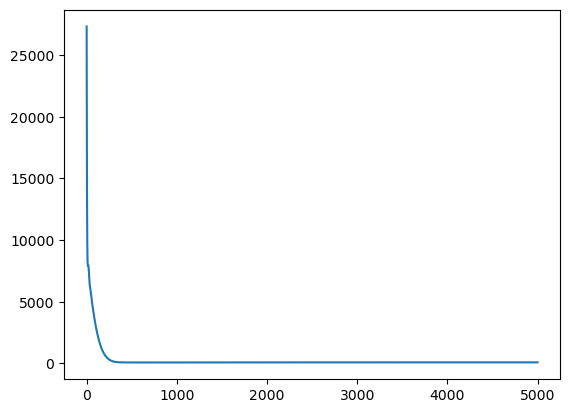

In [227]:
import torch 
from torch import nn

s = torch.randn(img.shape, requires_grad=True)

Theta_rows_torch = torch.tensor(Theta_rows).to(torch.float)
Theta_cols_torch = torch.tensor(Theta_cols).to(torch.float)
y_sample = torch.tensor(y).to(torch.float)

optim = torch.optim.Adam([s], lr=0.03)

mse = nn.MSELoss()

lam = 0.5

history = []

for i in range(5000):

    y_sample_recon = Theta_rows_torch @ s @ Theta_cols_torch

    loss = lam * torch.mean((y_sample_recon - y_sample)**2) + torch.norm(s, p=1)

    history.append(loss.item())
    
    if i % 1000 == 0: print(i, history[-1])

    optim.zero_grad()
    loss.backward()
    optim.step()

plt.plot(history)

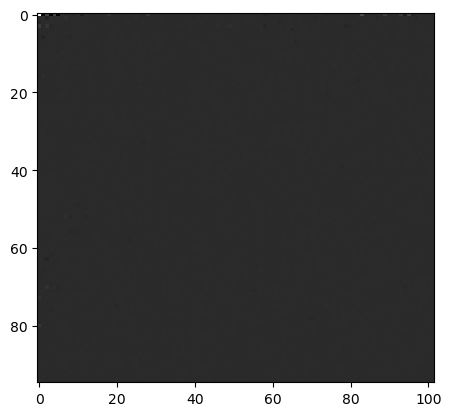

In [228]:
plt.imshow(s.detach().numpy(), cmap='gray')

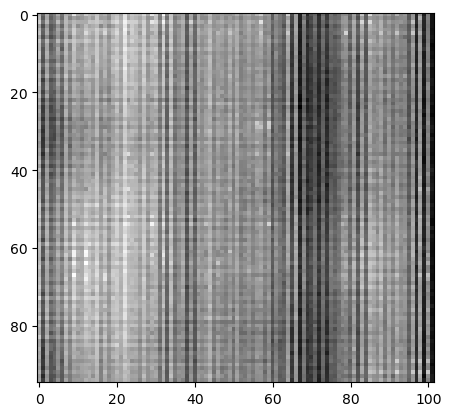

In [229]:
fx_recon = Psi_rows @ s.detach().numpy() @ Psi_cols

plt.imshow(fx_recon, cmap='gray')

In [38]:
import cvxpy as cvx

In [39]:
nx, ny = img.shape

# extract small sample of signal
k = round(nx * ny * 0.5) # 50% sample
ri = np.random.choice(nx * ny, k, replace=False) # random sample of indices
b = img.T.flat[ri]

In [40]:
import scipy.fftpack as spfft

# create dct matrix operator using kron (memory errors for large ny*nx)
A = np.kron(
    spfft.idct(np.identity(nx), norm='ortho', axis=0),
    spfft.idct(np.identity(ny), norm='ortho', axis=0)
    )
A = A[ri,:] # same as phi times kron

In [41]:
A.shape, b.shape

((1767, 3534), (1767,))

In [42]:
s = cvx.Variable(img.shape[0] * img.shape[1])

obj = cvx.Minimize(cvx.norm(s, 1))
constraints = [(A @ s) == b]
prob = cvx.Problem(obj, constraints)
result = prob.solve(verbose=False, solver="SCS")

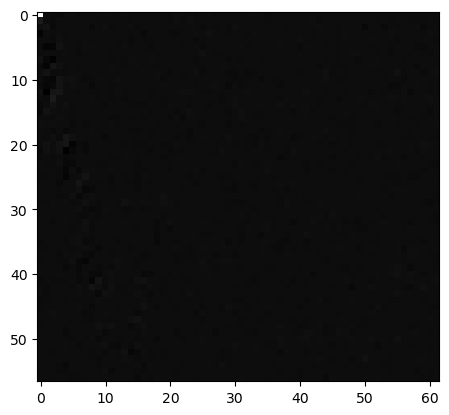

In [43]:
plt.imshow(s.value.reshape(img.shape), cmap='gray')

In [44]:
def idct2(x):
    return spfft.idct(spfft.idct(x.T, norm='ortho', axis=0).T, norm='ortho', axis=0)

Xa = idct2(s.value.reshape(img.shape).T)
Xa.shape

(62, 57)

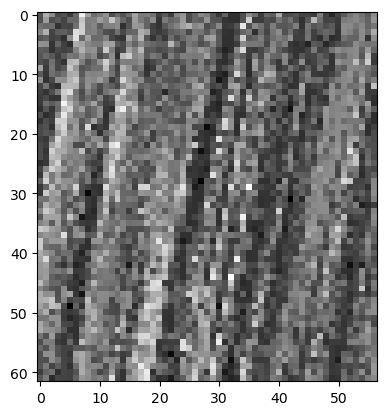

In [45]:
# fx_recon = Psi_rows @ s.value.reshape(img.shape) @ Psi_cols

plt.imshow(Xa, cmap='gray')